## K Means Clustering Implementation

In [2]:
import matplotlib.pyplot as plt 
from sklearn.datasets import make_blobs
import pandas as pd 
import numpy as np
%matplotlib inline

In [3]:
X,y = make_blobs(n_samples=1000,centers=3,n_features=2)

In [4]:
X

array([[-5.17855585,  6.46612252],
       [-6.56082943,  4.24891857],
       [-6.83873798,  4.80904322],
       ...,
       [-3.17794619,  4.48997961],
       [-4.32190224,  4.41001996],
       [ 7.88103728, -7.11688781]], shape=(1000, 2))

In [5]:
y

array([1, 1, 1, 0, 0, 0, 2, 0, 2, 2, 1, 0, 1, 1, 2, 2, 0, 0, 1, 2, 1, 0,
       2, 1, 2, 0, 2, 1, 2, 2, 0, 0, 1, 2, 2, 0, 2, 2, 0, 2, 2, 1, 0, 1,
       1, 1, 0, 0, 2, 0, 2, 2, 1, 2, 2, 1, 0, 2, 0, 0, 2, 1, 1, 2, 1, 0,
       0, 0, 2, 2, 1, 1, 0, 1, 2, 2, 2, 1, 1, 0, 2, 1, 0, 1, 2, 2, 1, 0,
       1, 1, 1, 2, 0, 0, 0, 2, 0, 1, 0, 1, 1, 0, 0, 0, 2, 2, 2, 0, 0, 1,
       2, 1, 1, 2, 2, 0, 1, 1, 0, 2, 2, 2, 0, 2, 2, 1, 1, 0, 2, 0, 1, 1,
       2, 0, 0, 0, 1, 1, 0, 2, 2, 0, 2, 0, 2, 0, 2, 0, 1, 2, 2, 2, 2, 2,
       1, 1, 0, 1, 1, 2, 1, 1, 0, 0, 2, 1, 1, 2, 2, 0, 0, 1, 1, 1, 2, 2,
       2, 2, 2, 2, 2, 0, 1, 2, 0, 2, 1, 0, 0, 2, 2, 1, 2, 0, 0, 1, 2, 1,
       0, 0, 2, 1, 2, 1, 0, 1, 2, 2, 0, 2, 2, 1, 1, 0, 2, 2, 1, 2, 0, 0,
       2, 2, 1, 0, 2, 1, 1, 0, 2, 1, 2, 0, 0, 0, 1, 2, 1, 1, 1, 0, 2, 0,
       0, 1, 0, 1, 0, 1, 2, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 2, 1, 1, 2,
       0, 0, 1, 2, 2, 2, 0, 2, 1, 2, 2, 0, 2, 2, 1, 1, 1, 0, 1, 0, 0, 0,
       1, 1, 1, 1, 1, 0, 1, 1, 2, 2, 1, 0, 1, 2, 2,

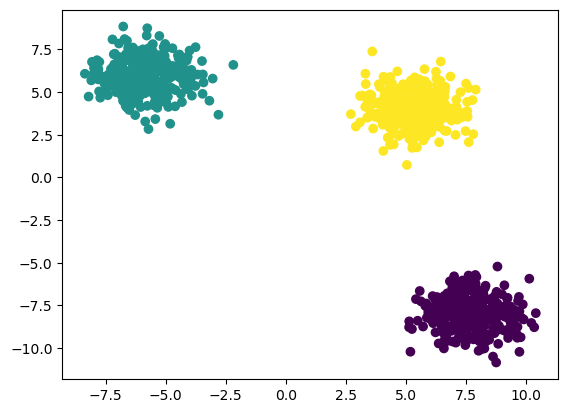

In [8]:
plt.scatter(X[:,0],X[:,1],c=y)

In [9]:
## Standardization - Feature scaling technique
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

array([[-1.26704813,  0.93215307],
       [-1.49819022,  0.57829711],
       [-1.54466174,  0.66769053],
       ...,
       [-0.93250865,  0.61676939],
       [-1.12379957,  0.60400818],
       [ 0.91676095, -1.23563537]], shape=(1000, 2))

In [12]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size = 0.3,random_state = 42)

In [14]:
X_scaled_data = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
from sklearn.cluster import KMeans

In [17]:
## Elbow method to select the K value
wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_scaled_data)
    wcss.append(kmeans.inertia_)

B:\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
B:\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
B:\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
B:\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than 

In [18]:
wcss

[1400.0,
 461.31800311428043,
 36.601075193358454,
 32.321302791423555,
 28.45762419971051,
 24.714426991885023,
 23.55206032733319,
 19.30612518597878,
 17.56368565225385,
 15.435457827346244]

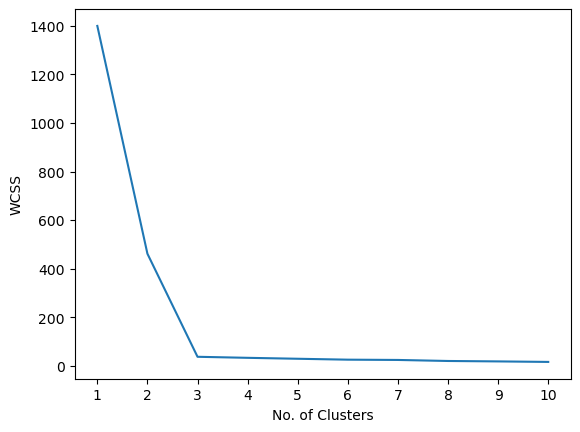

In [19]:
## plot elbow curve
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("No. of Clusters")
plt.ylabel("WCSS")
plt.show()

In [20]:
kmeans = KMeans(n_clusters=3,init="k-means++")

In [21]:
kmeans.fit_predict(X_scaled_data)

B:\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


array([1, 1, 2, 1, 2, 2, 0, 0, 0, 2, 1, 2, 0, 0, 2, 2, 0, 0, 0, 2, 1, 2,
       2, 0, 2, 0, 1, 1, 2, 1, 1, 2, 0, 2, 2, 0, 1, 1, 1, 2, 2, 0, 2, 2,
       1, 2, 2, 0, 2, 1, 1, 0, 1, 0, 1, 2, 0, 2, 0, 0, 0, 1, 1, 2, 0, 0,
       1, 1, 1, 1, 1, 1, 0, 2, 0, 0, 2, 2, 1, 1, 2, 1, 0, 2, 0, 0, 2, 0,
       2, 1, 0, 2, 0, 1, 1, 1, 2, 1, 1, 2, 0, 1, 1, 0, 0, 2, 1, 0, 0, 1,
       0, 2, 0, 1, 2, 0, 1, 0, 1, 2, 2, 1, 2, 1, 2, 1, 2, 2, 2, 2, 1, 1,
       1, 2, 2, 2, 2, 1, 1, 1, 1, 0, 0, 2, 0, 2, 1, 0, 1, 2, 1, 0, 0, 1,
       0, 0, 0, 0, 1, 1, 0, 0, 2, 2, 2, 0, 0, 0, 1, 0, 0, 1, 1, 2, 1, 1,
       1, 1, 1, 2, 2, 1, 1, 1, 0, 2, 1, 0, 0, 1, 1, 2, 2, 2, 1, 0, 1, 1,
       2, 0, 1, 0, 1, 1, 2, 0, 0, 1, 1, 0, 2, 0, 2, 0, 2, 2, 2, 0, 2, 0,
       1, 1, 2, 2, 2, 2, 2, 2, 2, 1, 1, 0, 2, 1, 1, 1, 0, 0, 0, 0, 1, 0,
       2, 2, 2, 0, 1, 2, 2, 2, 2, 1, 0, 0, 1, 0, 0, 0, 1, 1, 2, 1, 2, 1,
       0, 1, 0, 1, 2, 2, 0, 0, 2, 0, 0, 0, 0, 1, 2, 1, 2, 0, 1, 2, 1, 0,
       1, 1, 1, 0, 2, 2, 0, 1, 2, 2, 2, 1, 2, 2, 1,

In [22]:
y_pred = kmeans.predict(X_scaled_data)

In [23]:
y_pred

array([1, 1, 2, 1, 2, 2, 0, 0, 0, 2, 1, 2, 0, 0, 2, 2, 0, 0, 0, 2, 1, 2,
       2, 0, 2, 0, 1, 1, 2, 1, 1, 2, 0, 2, 2, 0, 1, 1, 1, 2, 2, 0, 2, 2,
       1, 2, 2, 0, 2, 1, 1, 0, 1, 0, 1, 2, 0, 2, 0, 0, 0, 1, 1, 2, 0, 0,
       1, 1, 1, 1, 1, 1, 0, 2, 0, 0, 2, 2, 1, 1, 2, 1, 0, 2, 0, 0, 2, 0,
       2, 1, 0, 2, 0, 1, 1, 1, 2, 1, 1, 2, 0, 1, 1, 0, 0, 2, 1, 0, 0, 1,
       0, 2, 0, 1, 2, 0, 1, 0, 1, 2, 2, 1, 2, 1, 2, 1, 2, 2, 2, 2, 1, 1,
       1, 2, 2, 2, 2, 1, 1, 1, 1, 0, 0, 2, 0, 2, 1, 0, 1, 2, 1, 0, 0, 1,
       0, 0, 0, 0, 1, 1, 0, 0, 2, 2, 2, 0, 0, 0, 1, 0, 0, 1, 1, 2, 1, 1,
       1, 1, 1, 2, 2, 1, 1, 1, 0, 2, 1, 0, 0, 1, 1, 2, 2, 2, 1, 0, 1, 1,
       2, 0, 1, 0, 1, 1, 2, 0, 0, 1, 1, 0, 2, 0, 2, 0, 2, 2, 2, 0, 2, 0,
       1, 1, 2, 2, 2, 2, 2, 2, 2, 1, 1, 0, 2, 1, 1, 1, 0, 0, 0, 0, 1, 0,
       2, 2, 2, 0, 1, 2, 2, 2, 2, 1, 0, 0, 1, 0, 0, 0, 1, 1, 2, 1, 2, 1,
       0, 1, 0, 1, 2, 2, 0, 0, 2, 0, 0, 0, 0, 1, 2, 1, 2, 0, 1, 2, 1, 0,
       1, 1, 1, 0, 2, 2, 0, 1, 2, 2, 2, 1, 2, 2, 1,

ValueError: 'c' argument has 700 elements, which is inconsistent with 'x' and 'y' with size 300.

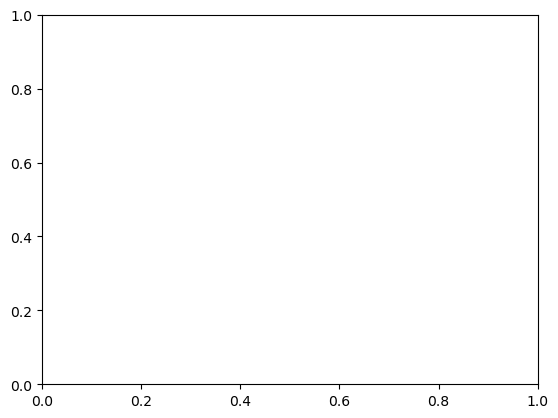

In [24]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred)